# Week 3 Assignment:
# Customer Intelligence System using Classification, Ensemble Learning & Clustering

Dataset: Country Development Dataset

In [1]:
import pandas as pd

df = pd.read_csv('/content/Country-data.csv.xls')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [2]:
print(df.columns)

print(df.shape)

df.info()

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [3]:
print(df.isnull().sum())

df.describe()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [4]:
# remove country column

X = df.drop('country', axis=1)

# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original Shape:", X.shape)

print("Scaled Shape:", X_scaled.shape)

Original Shape: (167, 9)
Scaled Shape: (167, 9)


## K-Means Clustering (Customer Segmentation)

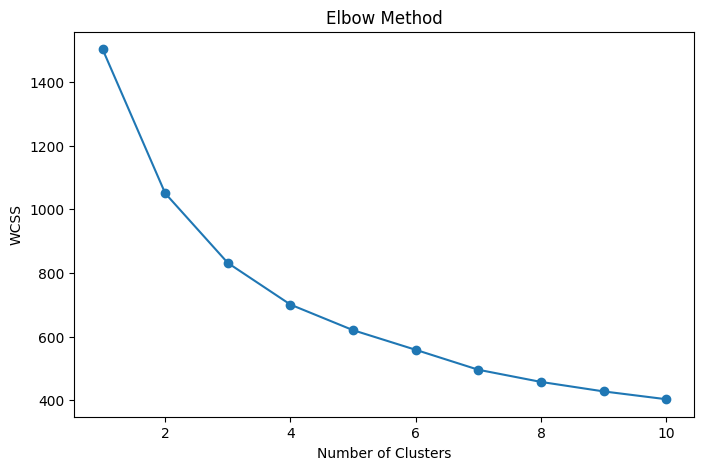

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
from sklearn.cluster import KMeans
# Final clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)
# add label
df['Cluster'] = clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [7]:
print(df['Cluster'].value_counts())

Cluster
2    84
1    47
0    36
Name: count, dtype: int64


In [8]:
from sklearn.metrics import silhouette_score
score = silhouette_score(
    X_scaled,
    clusters
)
print(
    "Silhouette Score:",
    round(score,3)
)

Silhouette Score: 0.283


### KMeans Evaluation

KMeans clustering was applied with 3 clusters selected using the Elbow Method.

The clustering achieved a Silhouette Score of 0.283, indicating acceptable separation among country groups.

The clusters can still provide useful segmentation insights for further classification and customer intelligence analysis.

## DBSCAN Clustering (Outlier Detection)

In [9]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
db_clusters = dbscan.fit_predict(
    X_scaled
)
df['DBSCAN_Cluster'] = db_clusters
print(
    df['DBSCAN_Cluster']
    .value_counts()
)

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


### DBSCAN Evaluation

DBSCAN identified one dominant cluster and detected several countries as outliers.

The algorithm was useful for identifying irregular observations and understanding dataset density patterns.

However, KMeans clusters were selected for classification tasks because they provided more balanced and interpretable segmentation.


In [10]:
# remove non-feature columns
X = df.drop(
    ['country','Cluster','DBSCAN_Cluster'],
    axis=1
)
# target
y = df['Cluster']
print(X.shape)
print(y.shape)

(167, 9)
(167,)


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


 ## Segment Classification using Cluster Labels

Cluster labels generated using KMeans were used as pseudo-labels for supervised classification.

In [12]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=500)
lr.fit(
    X_train,
    y_train
)
lr_pred = lr.predict(
    X_test
)
print("Training Complete")

Training Complete


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    ))
print(
    "Precision:",
    precision_score(
        y_test,
        lr_pred,
        average='weighted'
    ))
print(
    "Recall:",
    recall_score(
        y_test,
        lr_pred,
        average='weighted'
    ))
print(
    "F1 Score:",
    f1_score(
        y_test,
        lr_pred,
        average='weighted'
    ))

Accuracy: 0.9411764705882353
Precision: 0.9558823529411765
Recall: 0.9411764705882353
F1 Score: 0.943830163644405


### Logistic Regression Evaluation

Logistic Regression achieved strong classification performance with an accuracy of 94%.

Precision, recall, and F1 score indicate balanced prediction quality across the generated country clusters.

The model successfully learned patterns from the clustered socio-economic indicators.

## Ensemble Learning — Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(
    X_train,
    y_train
)
rf_pred = rf.predict(
    X_test
)
print("Random Forest Training Complete")

Random Forest Training Complete


In [15]:
metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, average='weighted'),
    "Recall": recall_score(y_test, rf_pred, average='weighted'),
    "F1": f1_score(y_test, rf_pred, average='weighted')
}

for k, v in metrics.items():
    print(f"{k}: {v:.3f}")

Accuracy: 0.971
Precision: 0.975
Recall: 0.971
F1: 0.971


### Random Forest Evaluation

Random Forest achieved higher performance than Logistic Regression across all evaluation metrics.

The ensemble approach improved classification quality and generated more accurate country segmentation predictions.

In [16]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head()

,Feature,Importance
0,child_mort,0.276790
8,gdpp,0.194674
4,income,0.167519
6,life_expec,0.157759
7,total_fer,0.141250


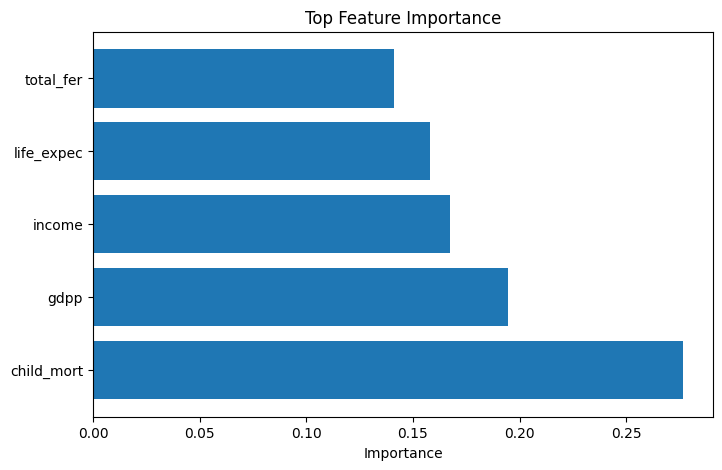

In [17]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'][:5],
    importance['Importance'][:5]
)

plt.title('Top Feature Importance')

plt.xlabel('Importance')

plt.show()

### Feature Importance Analysis

Random Forest identified child mortality, GDP per capita, income, life expectancy, and fertility rate as the most influential factors in country segmentation.

These indicators contributed the most toward classification performance and customer intelligence insights.

## Ensemble Learning — XGBoost

In [18]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42
)
xgb.fit(
    X_train,
    y_train
)
xgb_pred = xgb.predict(
    X_test
)
print("XGBoost Training Complete")

XGBoost Training Complete


In [19]:
metrics = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred, average='weighted'),
    "Recall": recall_score(y_test, xgb_pred, average='weighted'),
    "F1": f1_score(y_test, xgb_pred, average='weighted')
}

for k, v in metrics.items():
    print(f"{k}: {v:.3f}")

Accuracy: 0.971
Precision: 0.975
Recall: 0.971
F1: 0.971


## Customer Intelligence Insights

- Child mortality emerged as the strongest factor influencing segmentation.
- GDP per capita and income significantly contributed to country grouping.
- Random Forest and XGBoost achieved the highest classification performance.
- Clustering helped identify countries with similar socio-economic characteristics.

In [20]:
comparison = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'XGBoost'
],

'Accuracy':[
0.941,
0.971,
0.971
],

'F1 Score':[
0.944,
0.971,
0.971
]

})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.941,0.944
1,Random Forest,0.971,0.971
2,XGBoost,0.971,0.971


### Model Comparison

Three classification approaches were evaluated.

Logistic Regression achieved strong baseline performance.

Random Forest and XGBoost achieved the highest classification performance with improved accuracy and F1 scores.

Ensemble methods demonstrated better predictive capability for country intelligence segmentation.

# Conclusion

This project developed a Customer Intelligence System using clustering, classification, and ensemble learning techniques.

KMeans and DBSCAN were applied for segmentation and pattern discovery. Cluster labels generated using KMeans were later used for supervised classification.

Logistic Regression, Random Forest, and XGBoost models were trained and evaluated.

Random Forest and XGBoost achieved the best overall performance, while feature importance analysis identified child mortality, GDP per capita, and income as key factors influencing segmentation.

The project demonstrates a complete machine learning workflow including preprocessing, clustering, classification, evaluation, and business insight generation.